<a href="https://colab.research.google.com/github/FDB1228/Optimization_methods/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%963.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Лабораторная работа №3. Сопряженные направления**



Выполнил: студент группы Фн2-61 Тихомиров С.И.

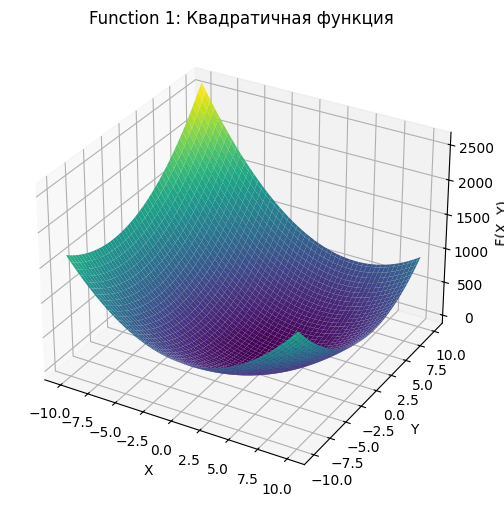

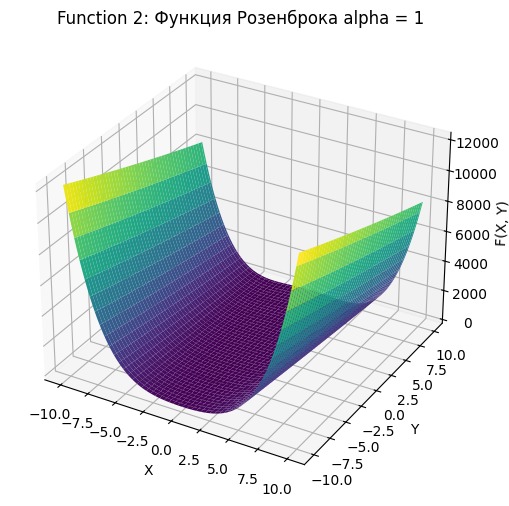

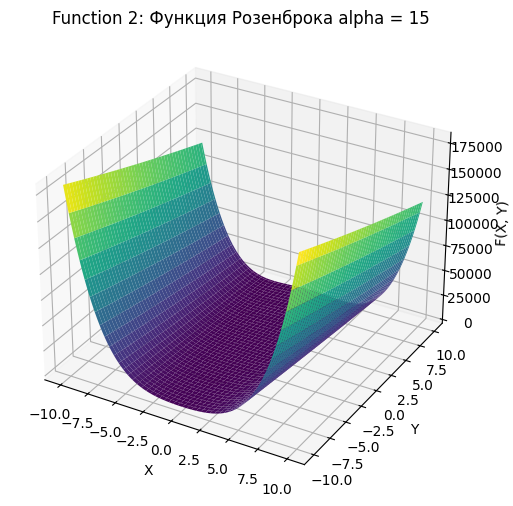

In [ ]:
# @title Визуализиция графиков квадратичной функции и функции Розенброка
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from typing import Callable, List, Tuple
from numpy.linalg import norm

# Определяем функции
def f1(x: np.ndarray) -> float:
    """Квадаратичная функция"""
    return (
        10 * x[0] ** 2
        - 4 * x[0] * x[1]
        + 7 * x[1] ** 2
        - 4 * np.sqrt(5) * (5 * x[0] - x[1])
        - 16
    )

def f2(x: np.ndarray) -> float:
    """Функция Розенброка alpha = 1"""
    return (x[0] ** 2 - x[1]) ** 2 + (x[0] - 1) ** 2

def f3(x: np.ndarray) -> float:
    """Функция Розенброка alpha = 15"""
    return 15 * (x[0] ** 2 - x[1]) ** 2 + (x[0] - 1) ** 2


# Определяем компоненты градиента
def f1dx(x: np.ndarray) -> float:
    return 20 * x[0] - 4 * x[1] - 20 * np.sqrt(5)

def f1dy(x: np.ndarray) -> float:
    return -4 * x[0] + 14 * x[1] + 4 * np.sqrt(5)

def f2dx(x: np.ndarray) -> float:
    return 4 * x[0] * ((x[0] ** 2) - x[1]) + 2 * (x[0] - 1)

def f2dy(x: np.ndarray) -> float:
    return -2 * ((x[0] ** 2) - x[1])

def f3dx(x: np.ndarray) -> float:
    return 60 * x[0] * ((x[0] ** 2) - x[1]) + 2 * (x[0] - 1)

def f3dy(x: np.ndarray) -> float:
    return -30 * ((x[0] ** 2) - x[1])

# генерация сетки
def generate_mesh_data(f: Callable[[np.ndarray], float],
                       x_range: Tuple[float, float] = (-10, 10),
                       y_range: Tuple[float, float] = (-10, 10),
                       resolution: int = 100) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Generates mesh grid data for a given function."""
    x = np.linspace(*x_range, resolution)
    y = np.linspace(*y_range, resolution)
    x_grid, y_grid = np.meshgrid(x, y)
    z = np.array([[f(np.array([x, y])) for x in x] for y in y])
    return x_grid, y_grid, z

# трехмерный график функции
def plot_3d_function(f: Callable[[np.ndarray], float], title: str = "3D Function Plot") -> None:
    """Plots a 3D surface of the given function."""
    x_grid, y_grid, z_grid = generate_mesh_data(f)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(x_grid, y_grid, z_grid, cmap='viridis')

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("F(X, Y)")
    ax.set_title(title)
    plt.show()

# Main execution
if __name__ == "__main__":
    plot_3d_function(f1, "Function 1: Квадратичная функция")
    plot_3d_function(f2, "Function 2: Функция Розенброка alpha = 1")
    plot_3d_function(f3, "Function 2: Функция Розенброка alpha = 15")



In [ ]:
# @title Реализиция методов сопряженных градиентов

def norm(v: np.ndarray) -> float:
    """Евклидова норма вектора"""
    return np.linalg.norm(v)


def dot(a: np.ndarray, b: np.ndarray) -> float:
    """Скалярное произведение двух векторов"""
    return float(np.dot(a, b))


def golden_section_search(
    f: Callable[[float], float], a: float, b: float, tol: float) -> float:
    """Метод золотого сечения"""
    phi = (1 + np.sqrt(5)) / 2
    resphi = 2 - phi
    f_evals = 2

    x1, x2 = a + resphi * (b - a), b - resphi * (b - a)
    f1, f2 = f(x1), f(x2)

    while abs(b - a) > tol:
        if f1 < f2:
            b, x2, f2 = x2, x1, f1
            x1 = a + resphi * (b - a)
            f1 = f(x1)
        else:
            a, x1, f1 = x1, x2, f2
            x2 = b - resphi * (b - a)
            f2 = f(x2)
        f_evals+=1
    return (a + b) / 2 , f_evals


def gradient_descent(
    f: Callable[[np.ndarray], float],
    fdx: Callable[[np.ndarray], float],
    fdy: Callable[[np.ndarray], float],
    x0: List[float],
    g: List[float],
    eps: float,
    border: float,
    k: int,
    max_iter: int = 5000
) -> np.ndarray:

    i = 0
    f_evals = 0
    grad_evals = 1
    opt = np.array(x0, dtype=float)
    w = -np.array([fdx(opt), fdy(opt)])
    w_norm = norm(w)
    p = w.copy()

    # Создание сетки
    fig, ax = plt.subplots(figsize=(8, 8))

    x_vals = np.linspace(g[0][0], g[0][1], 100)
    y_vals = np.linspace(g[1][0], g[1][1], 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.array([[f(np.array([x, y])) for x in x_vals] for y in y_vals])

    ax.scatter(*x0, color='blue', label="Начальное приближение")

    path = [opt.copy()]
    draw_iterations = []

    for iteration in range(max_iter):
        if w_norm <= eps:
            break

        # Линейный поиск с ограниченным диапазоном
        phi = lambda xi: f(opt + xi * p)
        xi, f_evals_k = golden_section_search(phi, 0, border, eps * 0.001)

        x_prev = opt.copy()
        x_start, y_start = x_prev[0], x_prev[1]

        opt += xi * p
        x_end, y_end = opt[0], opt[1]

        path.append(opt.copy())
        w_prev = w.copy()
        w = -np.array([fdx(opt), fdy(opt)])
        w_norm = norm(w)

        # Вычисление gamma
        if k == 1:
            gamma = dot(w, w) / dot(w_prev,p)
        elif k == 2:
            gamma = dot(w, w) / dot(w_prev, w_prev)
        elif k == 3:
            gamma = dot(w - w_prev, w) / dot(w_prev, w_prev)

        p = w + gamma * p
        f_evals += f_evals_k
        grad_evals += 1
        i += 1

        # отрисовка линии уровня
        if i <= 10:
            draw_iterations.append(i)
        else:
            if i % 30 == 0 or iteration == max_iter - 1 or w_norm <= eps:
                draw_iterations.append(i)


        ax.quiver(x_start, y_start, x_end - x_start, y_end - y_start,
                 angles='xy', scale_units='xy', scale=1, color='black', alpha=1, width = 0.005, headwidth = 2, zorder = 3)



        if i in draw_iterations:
            current_level = f(opt)
            cs = ax.contour(X, Y, Z, levels=[current_level], colors='green', linewidths=1)


    # финальная визуализация
    ax.scatter(*opt, color='red', label="Точка минимума", zorder = 3)



    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

    titles = {
        1: "Метод сопряженных градиентов",
        2: "Метод Флетчера-Ривса",
        3: "Метод Полака-Рибьера"
    }
    ax.set_title(titles.get(k, "Метод оптимизации"))

    plt.grid()
    plt.show()

    print(f"Начальное приближение: ({x0[0]},{x0[1]})")
    if eps == 1e-2:
        print(f"Точка минимума: x = {opt[0]:.2f}, y = {opt[1]:.2f}")
        print(f"Значение функции f(x,y)={f(opt):.2f}")
    else:
        print(f"Точка минимума: x = {opt[0]:.5f}, y = {opt[1]:.5f}")
        print(f"Значение функции f(x,y)={f(opt):.5f}")

    print(f"Количество вычислений функции: {f_evals}")
    print(f"Количество вычислений градиента: {grad_evals}")
    print(f"Количество итераций: {i}")

    return [x0, eps, i, f_evals, opt, f(opt)]

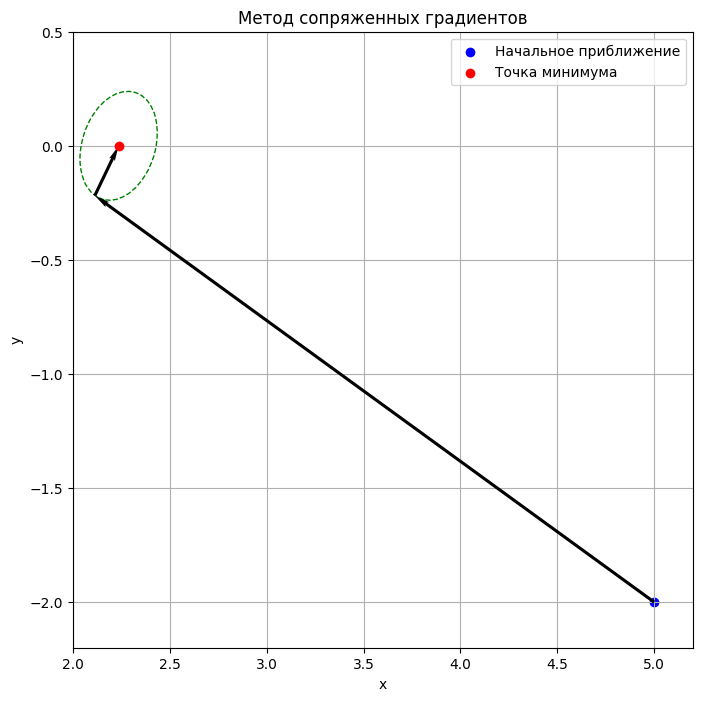

Начальное приближение: (5,-2)
Точка минимума: x = 2.24, y = -0.00
Значение функции f(x,y)=-66.00
Количество вычислений функции: 52
Количество вычислений градиента: 3
Количество итераций: 2


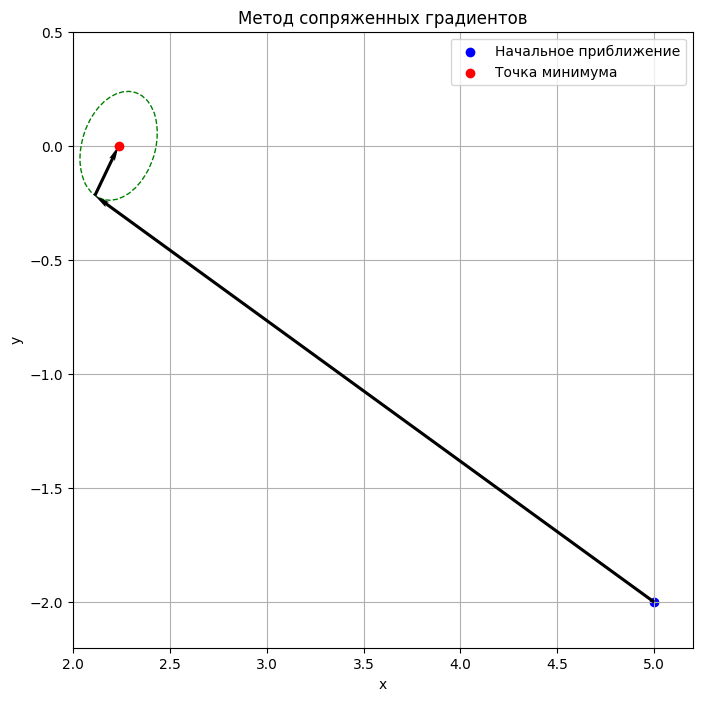

Начальное приближение: (5,-2)
Точка минимума: x = 2.23607, y = -0.00000
Значение функции f(x,y)=-66.00000
Количество вычислений функции: 80
Количество вычислений градиента: 3
Количество итераций: 2


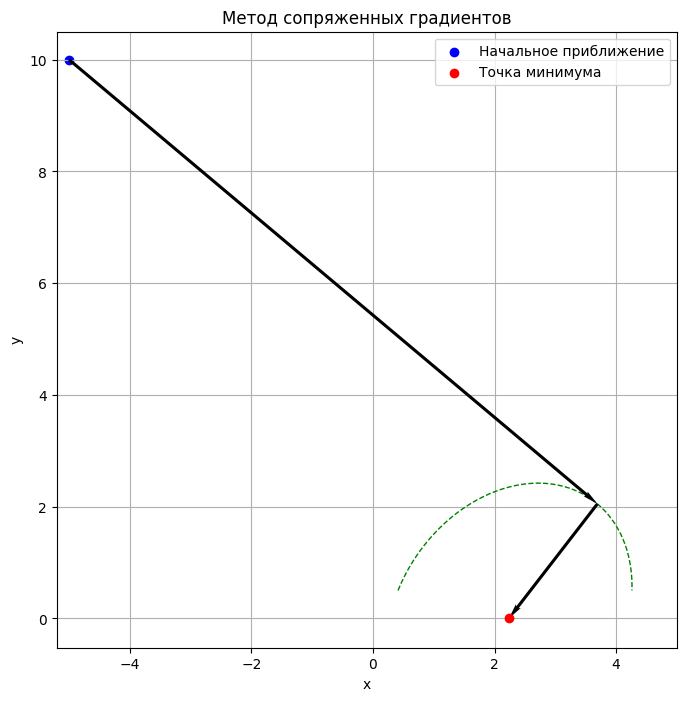

Начальное приближение: (-5,10)
Точка минимума: x = 2.24, y = 0.00
Значение функции f(x,y)=-66.00
Количество вычислений функции: 52
Количество вычислений градиента: 3
Количество итераций: 2


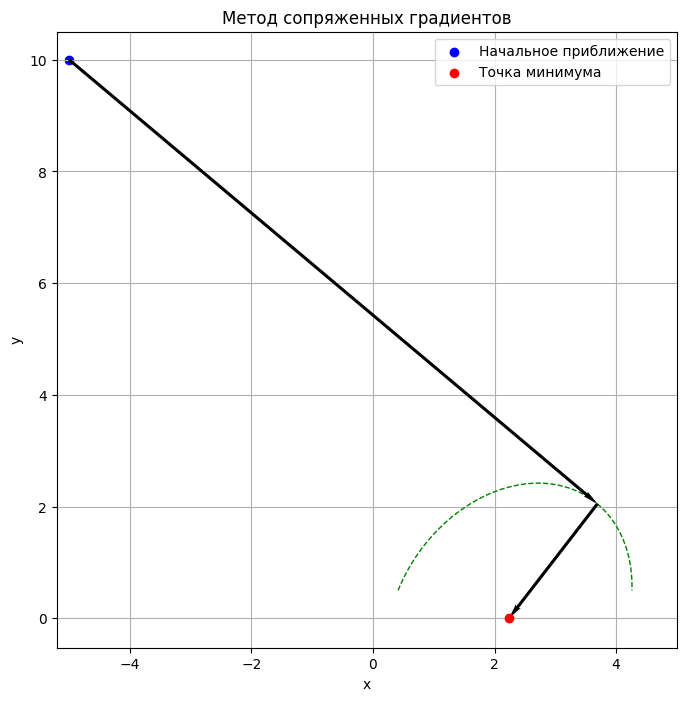

Начальное приближение: (-5,10)
Точка минимума: x = 2.23607, y = -0.00000
Значение функции f(x,y)=-66.00000
Количество вычислений функции: 80
Количество вычислений градиента: 3
Количество итераций: 2


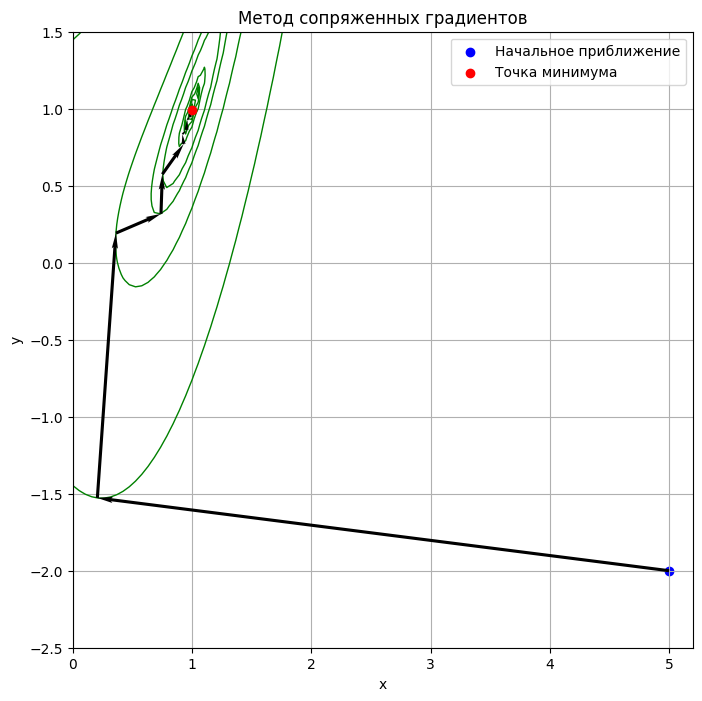

Начальное приближение: (5,-2)
Точка минимума: x = 1.00, y = 0.99
Значение функции f(x,y)=0.00
Количество вычислений функции: 338
Количество вычислений градиента: 14
Количество итераций: 13


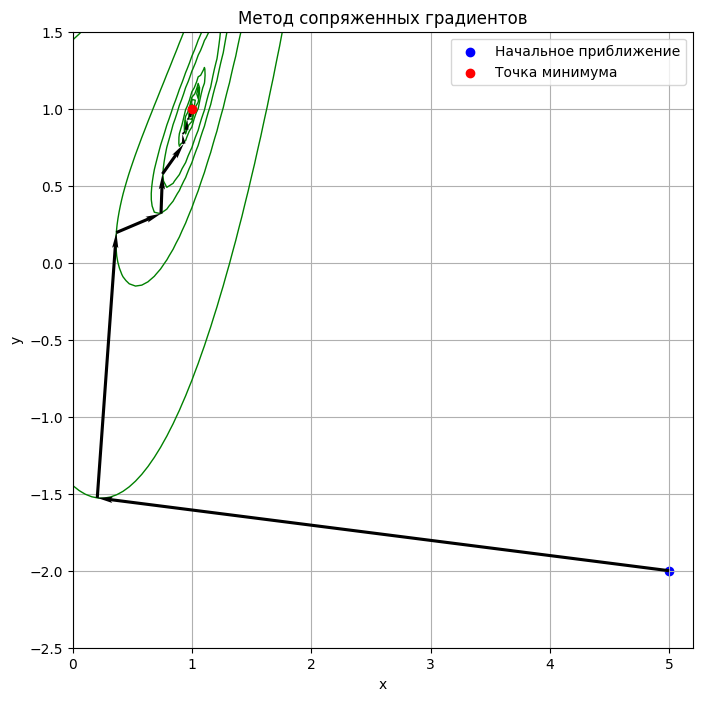

Начальное приближение: (5,-2)
Точка минимума: x = 1.00000, y = 0.99999
Значение функции f(x,y)=0.00000
Количество вычислений функции: 1280
Количество вычислений градиента: 33
Количество итераций: 32


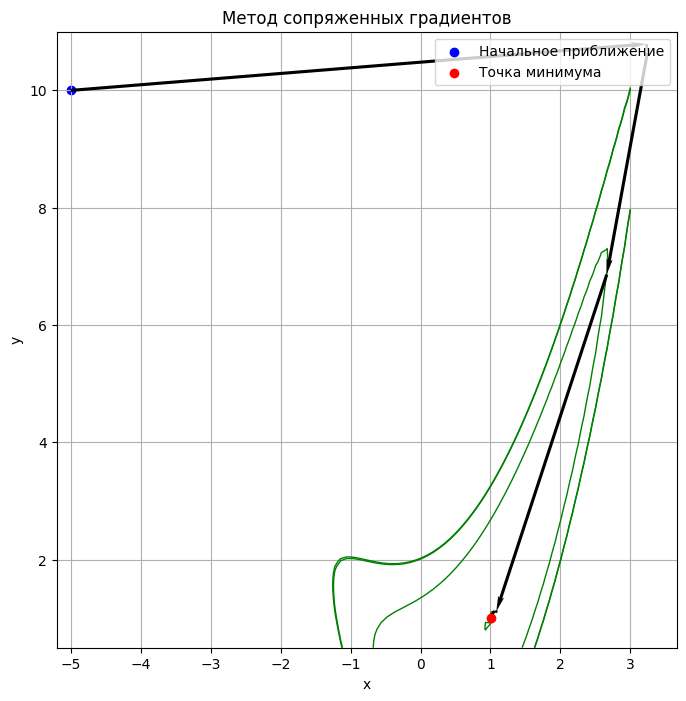

Начальное приближение: (-5,10)
Точка минимума: x = 1.00, y = 1.01
Значение функции f(x,y)=0.00
Количество вычислений функции: 312
Количество вычислений градиента: 14
Количество итераций: 13


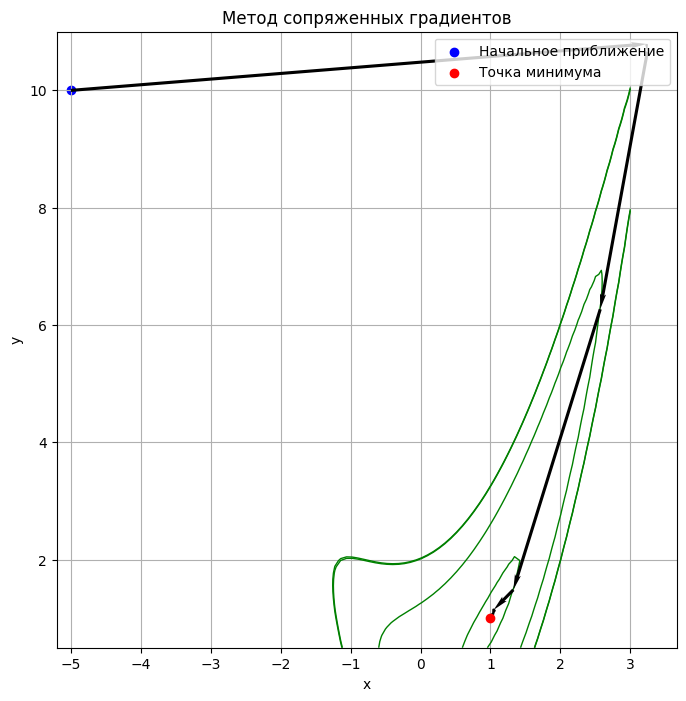

Начальное приближение: (-5,10)
Точка минимума: x = 1.00000, y = 1.00001
Значение функции f(x,y)=0.00000
Количество вычислений функции: 1209
Количество вычислений градиента: 32
Количество итераций: 31


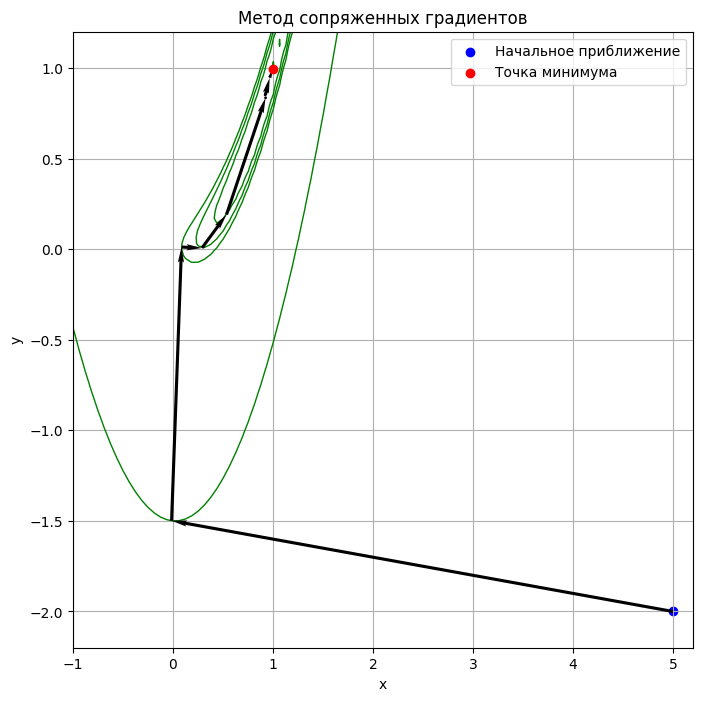

Начальное приближение: (5,-2)
Точка минимума: x = 1.00, y = 0.99
Значение функции f(x,y)=0.00
Количество вычислений функции: 260
Количество вычислений градиента: 11
Количество итераций: 10


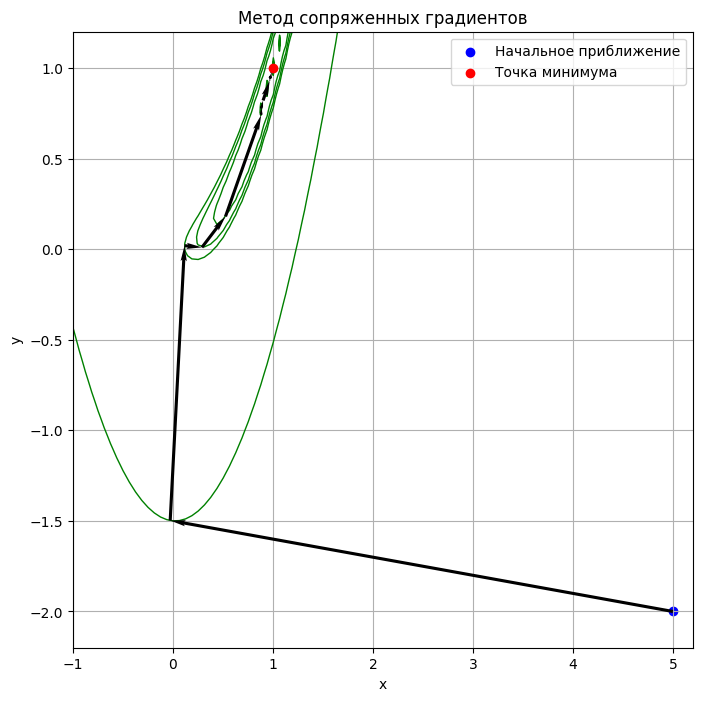

Начальное приближение: (5,-2)
Точка минимума: x = 1.00000, y = 0.99999
Значение функции f(x,y)=0.00000
Количество вычислений функции: 1760
Количество вычислений градиента: 45
Количество итераций: 44


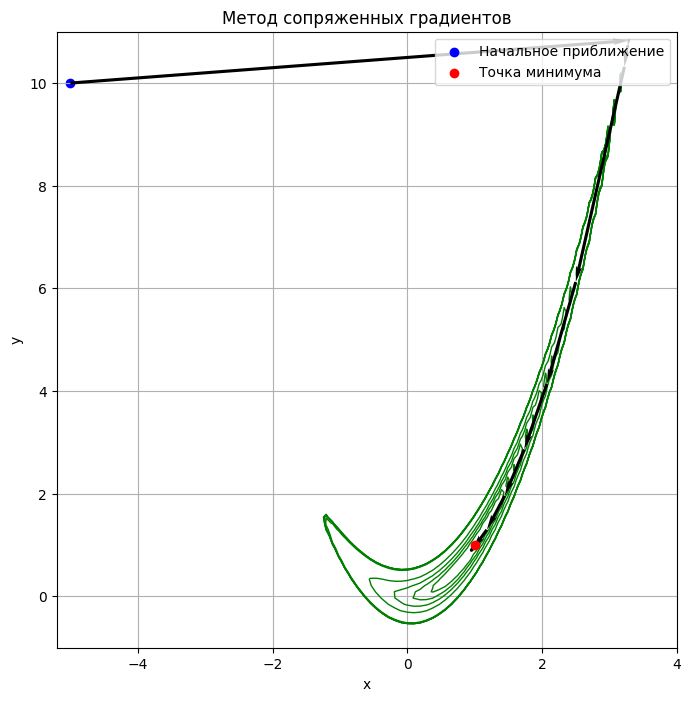

Начальное приближение: (-5,10)
Точка минимума: x = 1.00, y = 1.00
Значение функции f(x,y)=0.00
Количество вычислений функции: 858
Количество вычислений градиента: 40
Количество итераций: 39


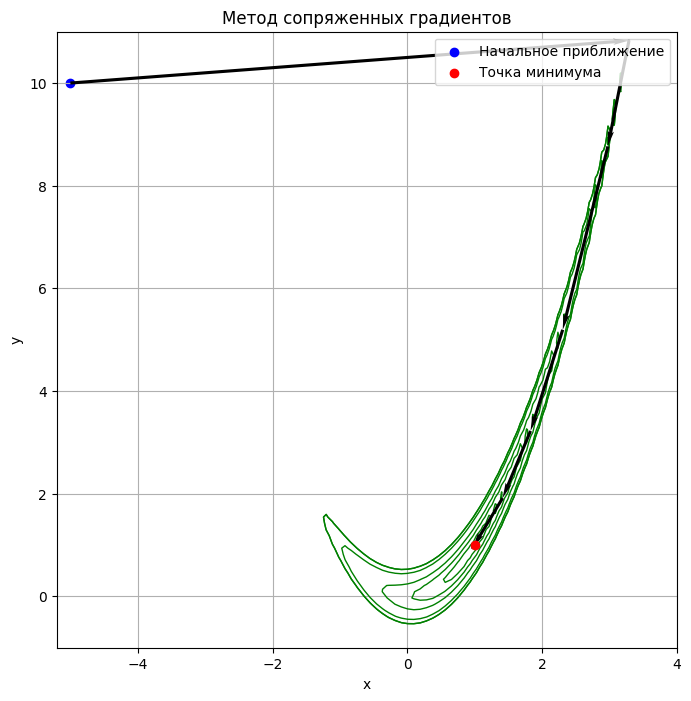

Начальное приближение: (-5,10)
Точка минимума: x = 1.00000, y = 1.00000
Значение функции f(x,y)=0.00000
Количество вычислений функции: 3441
Количество вычислений градиента: 94
Количество итераций: 93


In [ ]:
# @title Метод сопряженных градиентов

x1 = [5, -2]
x2 = [-5, 10]

eps1 = 1e-2
eps2 = 1e-5

g11 = [[2, 5.2],[-2.2, 0.5]]
g12 = [[-5.2, 5],[0.5, 10.5]]

g21 = [[0, 5.2],[-2.5, 1.5]]
g22 = [[-5.2, 3],[0.5, 11]]

g31 = [[-1, 5.2],[-2.2, 1.2]]
g32 = [[-5.2, 4],[-1, 11]]

f11 = gradient_descent(f1, f1dx, f1dy, x1, g11, eps1,0.7,1)
f12 = gradient_descent(f1, f1dx, f1dy, x1, g11, eps2,0.7,1)

f13 = gradient_descent(f1, f1dx, f1dy, x2, g12, eps1,0.7,1)
f14 = gradient_descent(f1, f1dx, f1dy, x2, g12, eps2,0.7,1)

f21 = gradient_descent(f2, f2dx, f2dy, x1, g21 ,eps1,0.85,1)
f22 = gradient_descent(f2, f2dx, f2dy, x1, g21, eps2,0.85,1)

f23 = gradient_descent(f2, f2dx, f2dy, x2, g22, eps1,0.3,1)
f24 = gradient_descent(f2, f2dx, f2dy, x2, g22, eps2,0.4,1)

f31 = gradient_descent(f3, f3dx, f3dy, x1, g31, eps1,0.8,1)
f32 = gradient_descent(f3, f3dx, f3dy, x1, g31, eps2,0.8,1)

f33 = gradient_descent(f3, f3dx, f3dy, x2, g32, eps1,0.15,1)
f34 = gradient_descent(f3, f3dx, f3dy, x2, g32, eps2,0.2,1)

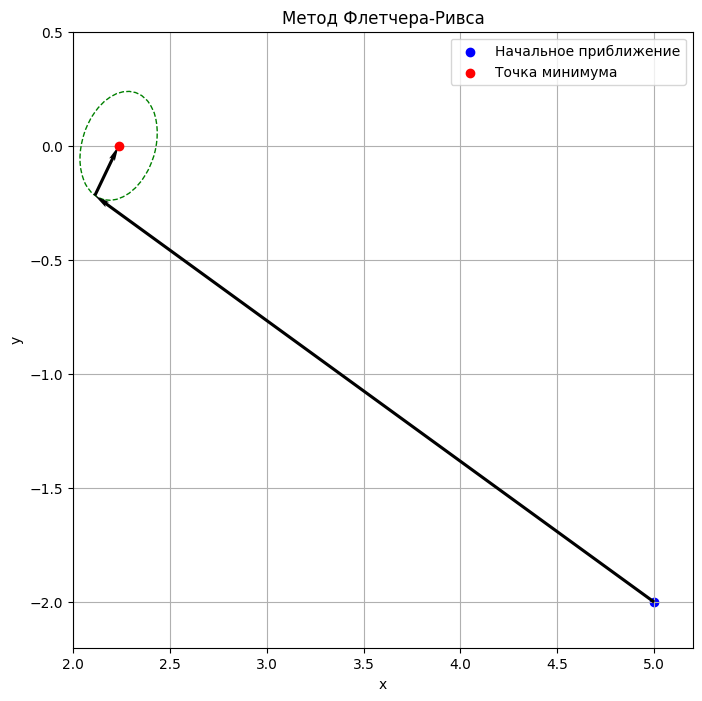

Начальное приближение: (5,-2)
Точка минимума: x = 2.24, y = -0.00
Значение функции f(x,y)=-66.00
Количество вычислений функции: 52
Количество вычислений градиента: 3
Количество итераций: 2


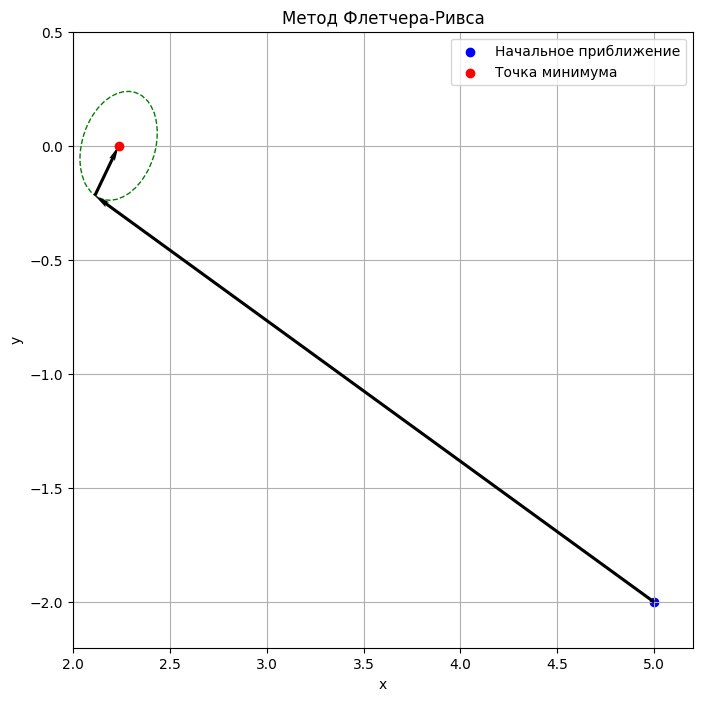

Начальное приближение: (5,-2)
Точка минимума: x = 2.23607, y = -0.00000
Значение функции f(x,y)=-66.00000
Количество вычислений функции: 80
Количество вычислений градиента: 3
Количество итераций: 2


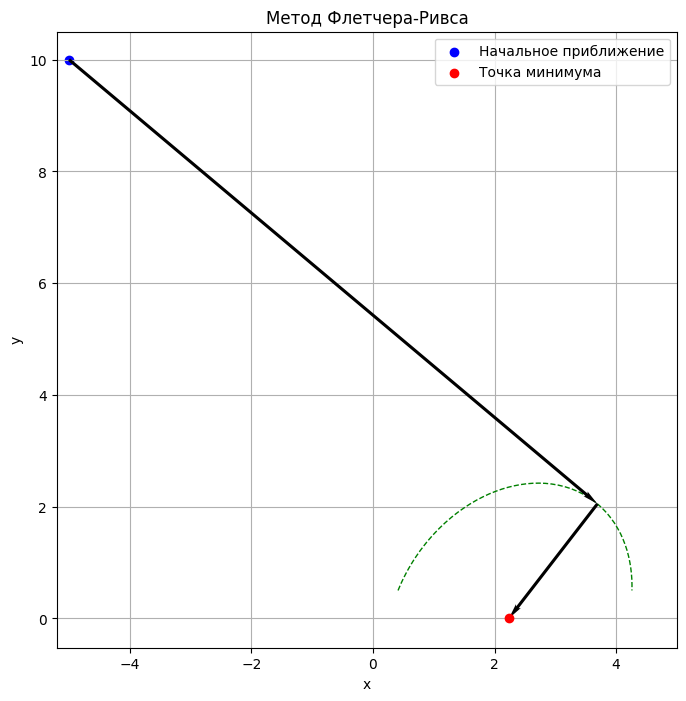

Начальное приближение: (-5,10)
Точка минимума: x = 2.24, y = 0.00
Значение функции f(x,y)=-66.00
Количество вычислений функции: 52
Количество вычислений градиента: 3
Количество итераций: 2


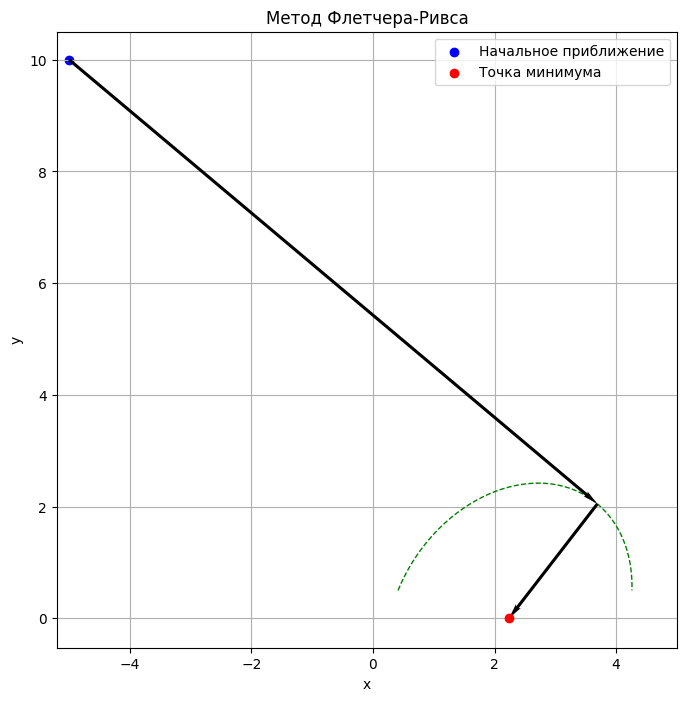

Начальное приближение: (-5,10)
Точка минимума: x = 2.23607, y = -0.00000
Значение функции f(x,y)=-66.00000
Количество вычислений функции: 80
Количество вычислений градиента: 3
Количество итераций: 2


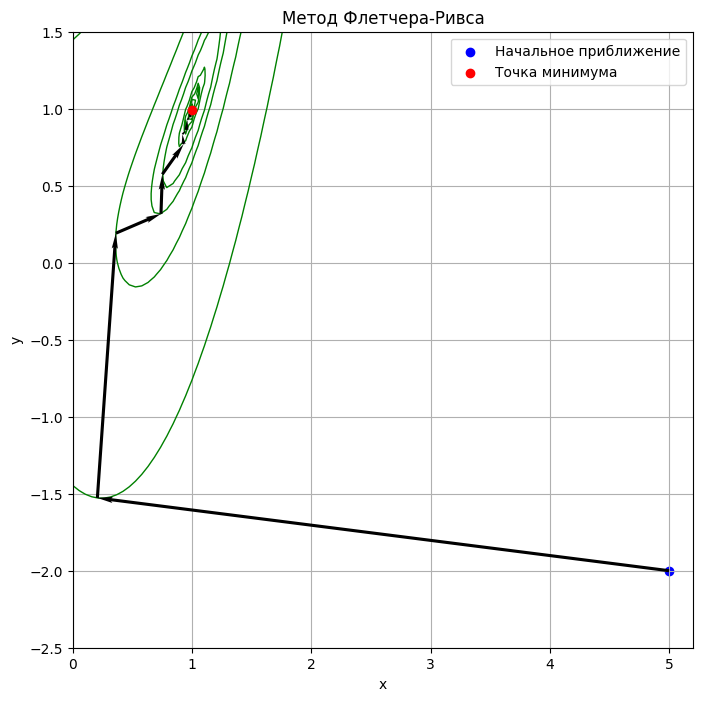

Начальное приближение: (5,-2)
Точка минимума: x = 1.00, y = 0.99
Значение функции f(x,y)=0.00
Количество вычислений функции: 351
Количество вычислений градиента: 14
Количество итераций: 13


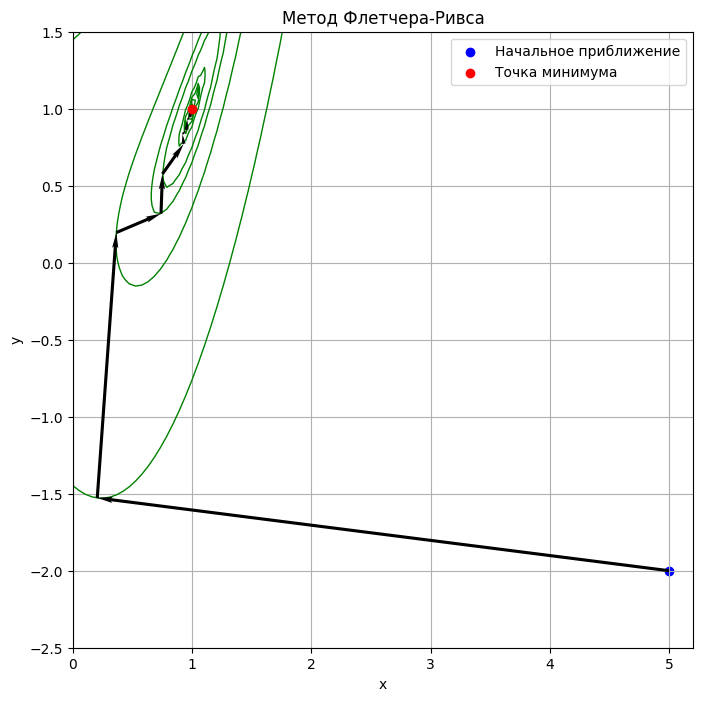

Начальное приближение: (5,-2)
Точка минимума: x = 1.00000, y = 0.99999
Значение функции f(x,y)=0.00000
Количество вычислений функции: 1312
Количество вычислений градиента: 33
Количество итераций: 32


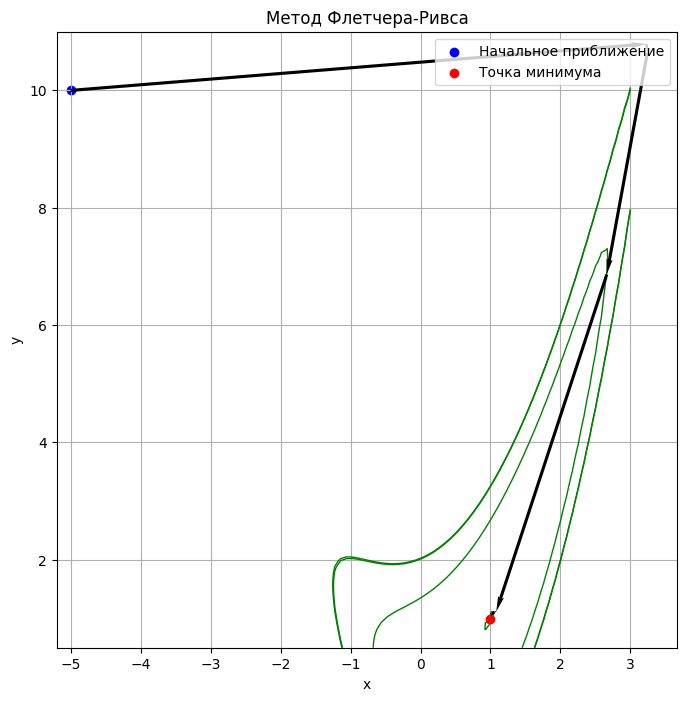

Начальное приближение: (-5,10)
Точка минимума: x = 1.00, y = 0.99
Значение функции f(x,y)=0.00
Количество вычислений функции: 264
Количество вычислений градиента: 12
Количество итераций: 11


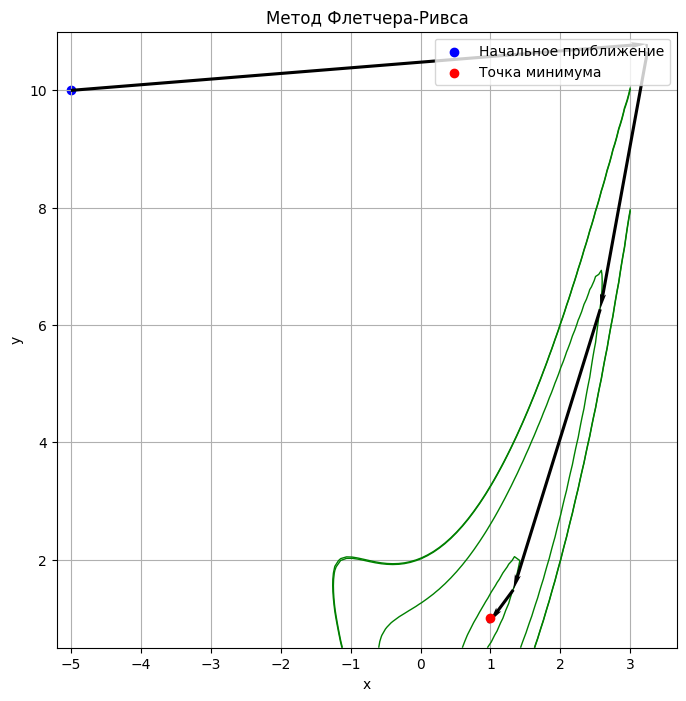

Начальное приближение: (-5,10)
Точка минимума: x = 1.00000, y = 1.00001
Значение функции f(x,y)=0.00000
Количество вычислений функции: 858
Количество вычислений градиента: 23
Количество итераций: 22


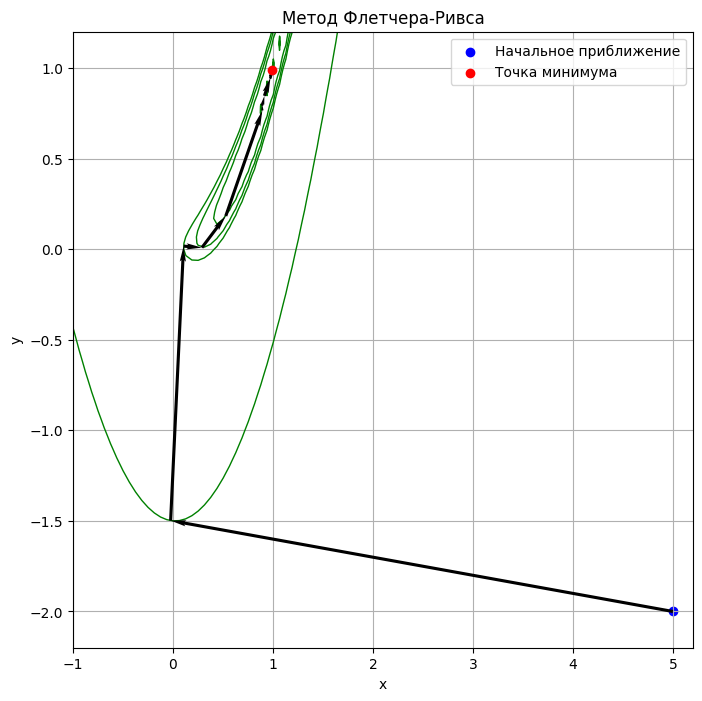

Начальное приближение: (5,-2)
Точка минимума: x = 1.00, y = 0.99
Значение функции f(x,y)=0.00
Количество вычислений функции: 432
Количество вычислений градиента: 17
Количество итераций: 16


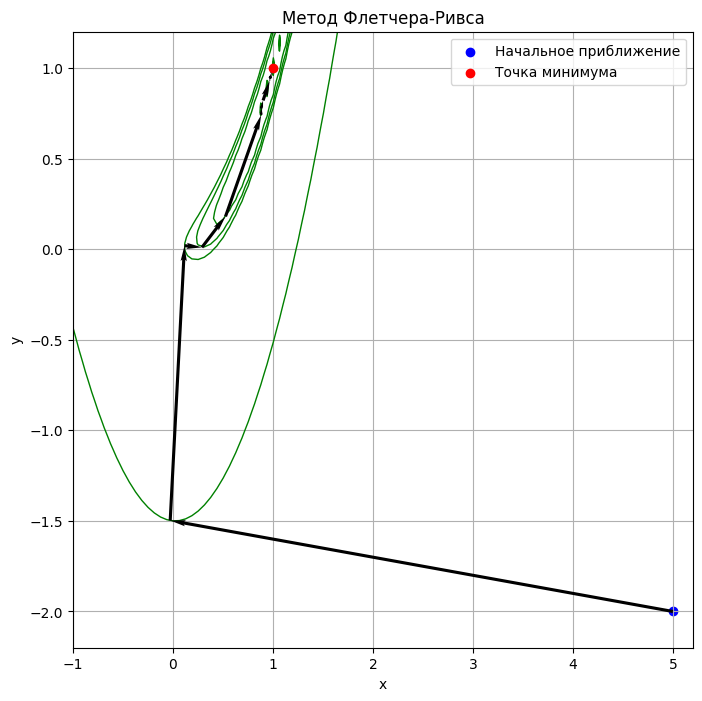

Начальное приближение: (5,-2)
Точка минимума: x = 1.00000, y = 0.99999
Значение функции f(x,y)=0.00000
Количество вычислений функции: 1804
Количество вычислений градиента: 45
Количество итераций: 44


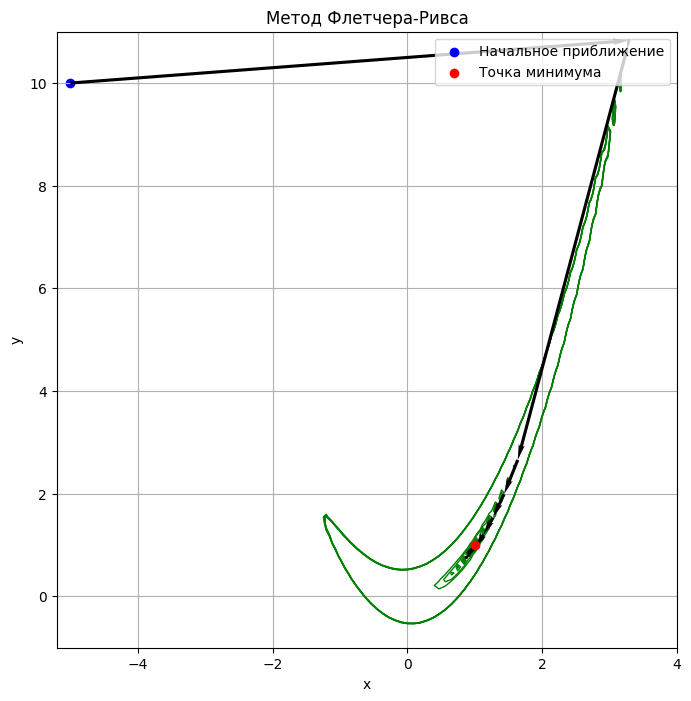

Начальное приближение: (-5,10)
Точка минимума: x = 1.00, y = 1.00
Значение функции f(x,y)=0.00
Количество вычислений функции: 552
Количество вычислений градиента: 24
Количество итераций: 23


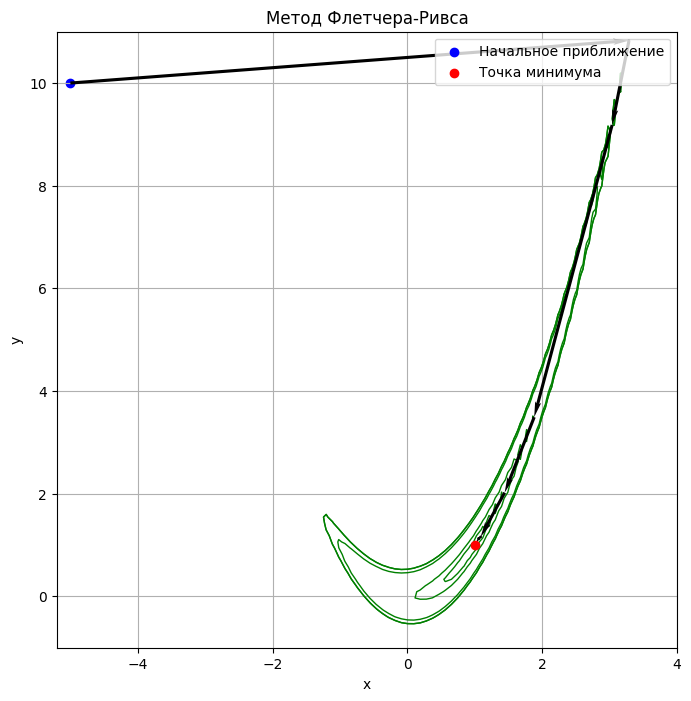

Начальное приближение: (-5,10)
Точка минимума: x = 1.00000, y = 1.00001
Значение функции f(x,y)=0.00000
Количество вычислений функции: 1702
Количество вычислений градиента: 47
Количество итераций: 46


In [ ]:
# @title Метод Флетчера-Ривса

f15 = gradient_descent(f1, f1dx, f1dy, x1, g11, eps1,0.7,2)
f16 = gradient_descent(f1, f1dx, f1dy, x1, g11, eps2,0.7,2)

f17 = gradient_descent(f1, f1dx, f1dy, x2, g12, eps1,0.7,2)
f18 = gradient_descent(f1, f1dx, f1dy, x2, g12, eps2,0.7,2)

f25 = gradient_descent(f2, f2dx, f2dy, x1, g21 ,eps1,1.15,2)
f26 = gradient_descent(f2, f2dx, f2dy, x1, g21, eps2,1.15,2)

f27 = gradient_descent(f2, f2dx, f2dy, x2, g22, eps1,0.3,2)
f28 = gradient_descent(f2, f2dx, f2dy, x2, g22, eps2,0.4,2)

f35 = gradient_descent(f3, f3dx, f3dy, x1, g31, eps1,1.2,2)
f36 = gradient_descent(f3, f3dx, f3dy, x1, g31, eps2,1.2,2)

f37 = gradient_descent(f3, f3dx, f3dy, x2, g32, eps1,0.25,2)
f38 = gradient_descent(f3, f3dx, f3dy, x2, g32, eps2,0.15,2)

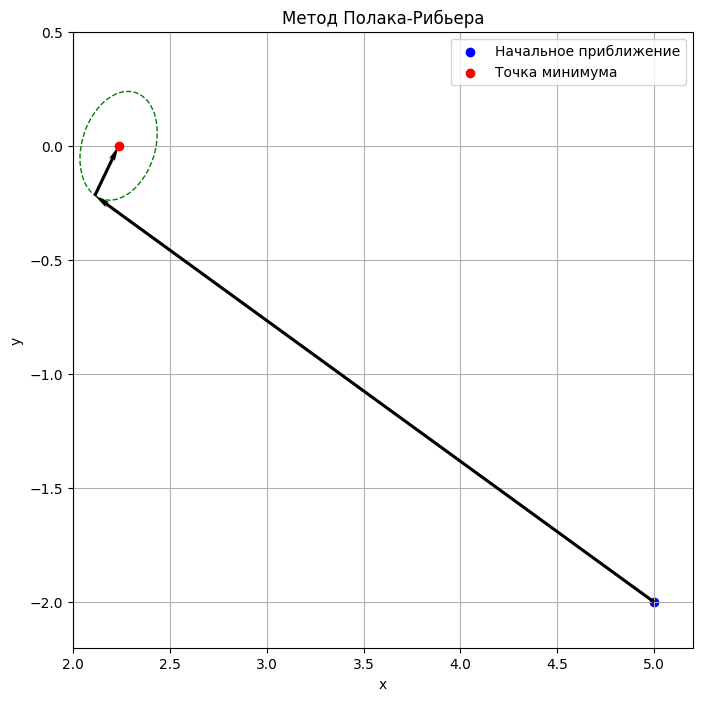

Начальное приближение: (5,-2)
Точка минимума: x = 2.24, y = 0.00
Значение функции f(x,y)=-66.00
Количество вычислений функции: 52
Количество вычислений градиента: 3
Количество итераций: 2


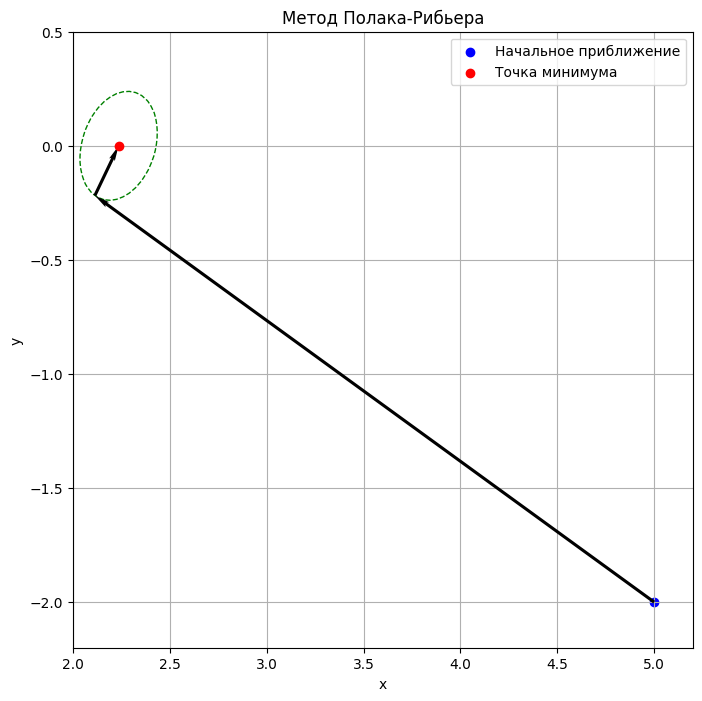

Начальное приближение: (5,-2)
Точка минимума: x = 2.23607, y = 0.00000
Значение функции f(x,y)=-66.00000
Количество вычислений функции: 80
Количество вычислений градиента: 3
Количество итераций: 2


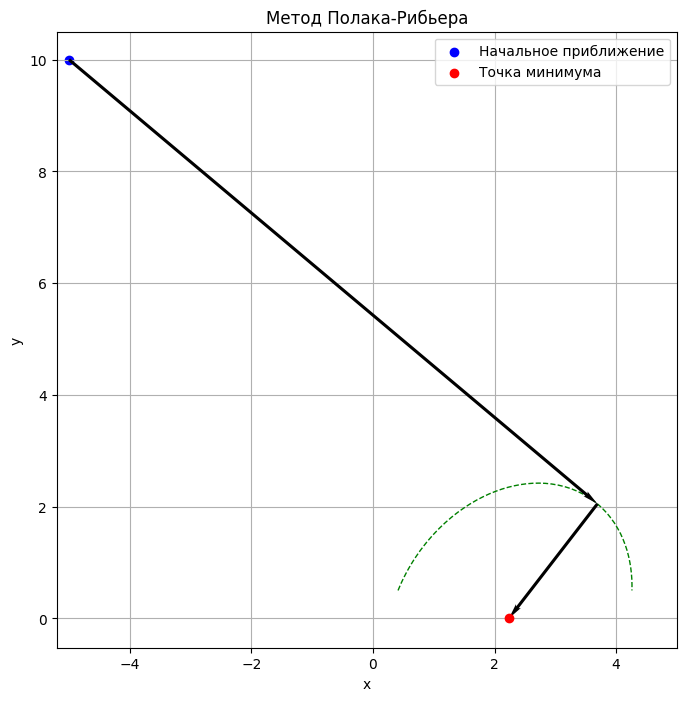

Начальное приближение: (-5,10)
Точка минимума: x = 2.24, y = -0.00
Значение функции f(x,y)=-66.00
Количество вычислений функции: 52
Количество вычислений градиента: 3
Количество итераций: 2


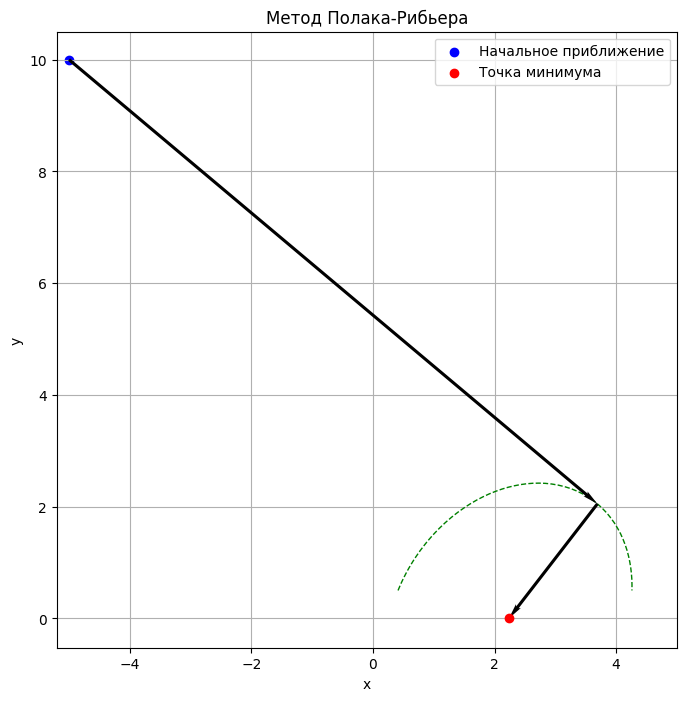

Начальное приближение: (-5,10)
Точка минимума: x = 2.23607, y = 0.00000
Значение функции f(x,y)=-66.00000
Количество вычислений функции: 80
Количество вычислений градиента: 3
Количество итераций: 2


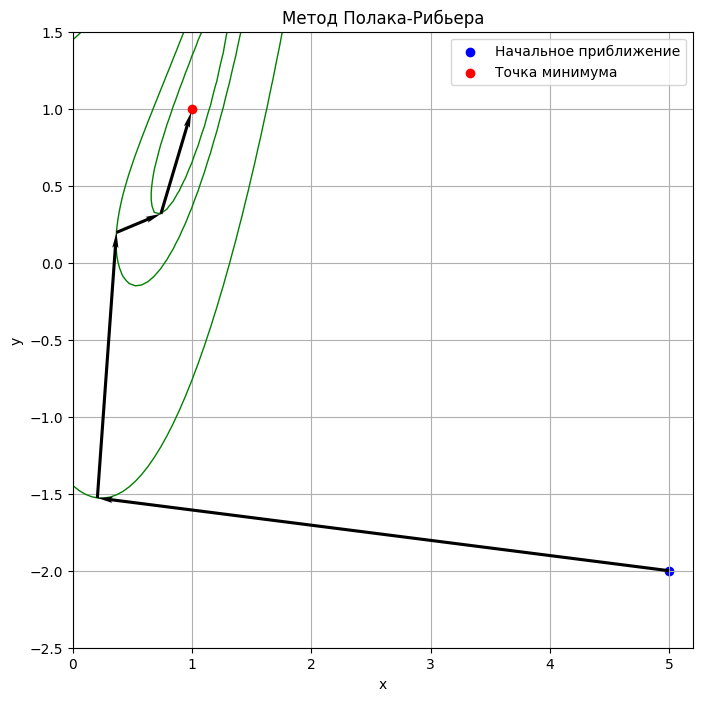

Начальное приближение: (5,-2)
Точка минимума: x = 1.00, y = 1.00
Значение функции f(x,y)=0.00
Количество вычислений функции: 189
Количество вычислений градиента: 8
Количество итераций: 7


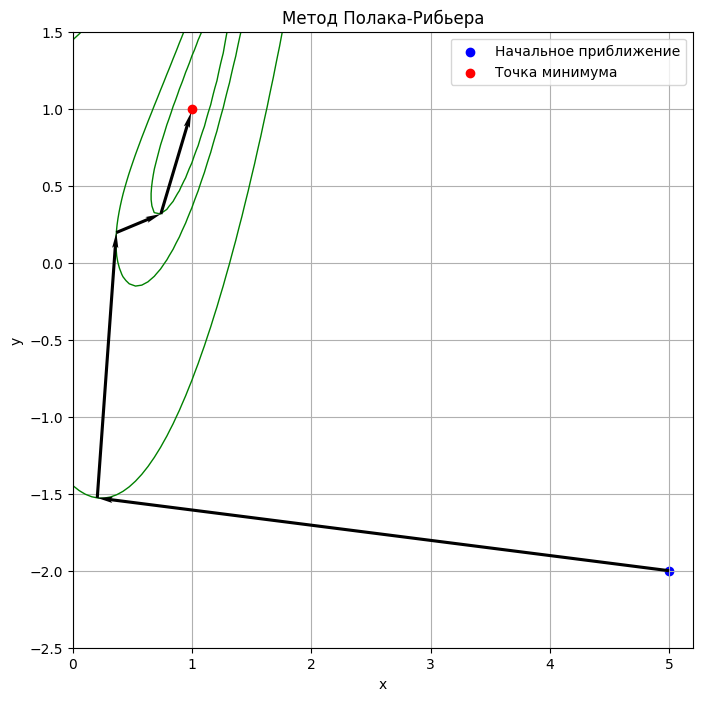

Начальное приближение: (5,-2)
Точка минимума: x = 1.00000, y = 1.00000
Значение функции f(x,y)=0.00000
Количество вычислений функции: 328
Количество вычислений градиента: 9
Количество итераций: 8


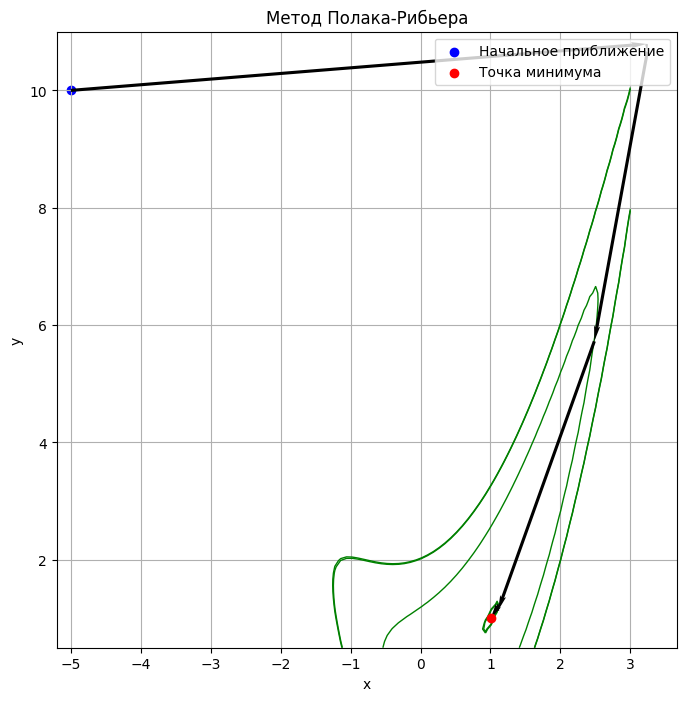

Начальное приближение: (-5,10)
Точка минимума: x = 1.00, y = 1.00
Значение функции f(x,y)=0.00
Количество вычислений функции: 175
Количество вычислений градиента: 8
Количество итераций: 7


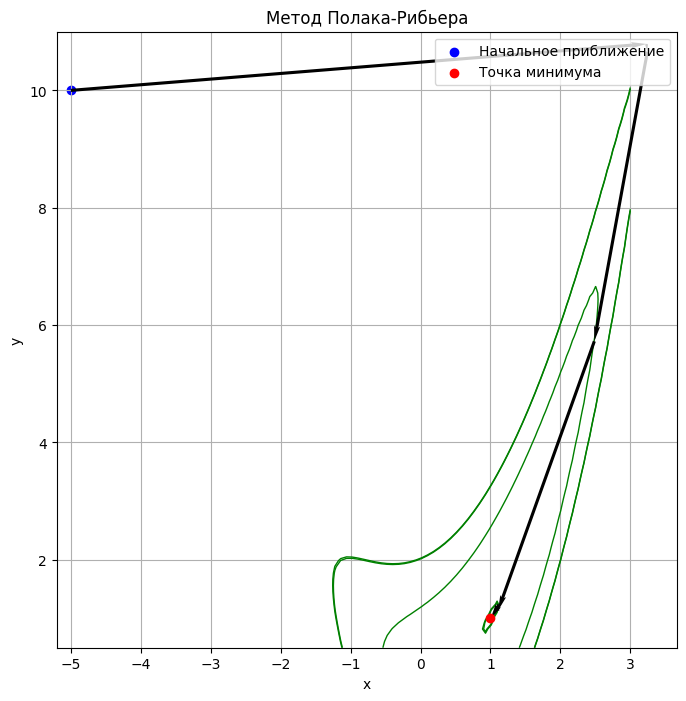

Начальное приближение: (-5,10)
Точка минимума: x = 1.00000, y = 1.00000
Значение функции f(x,y)=0.00000
Количество вычислений функции: 312
Количество вычислений градиента: 9
Количество итераций: 8


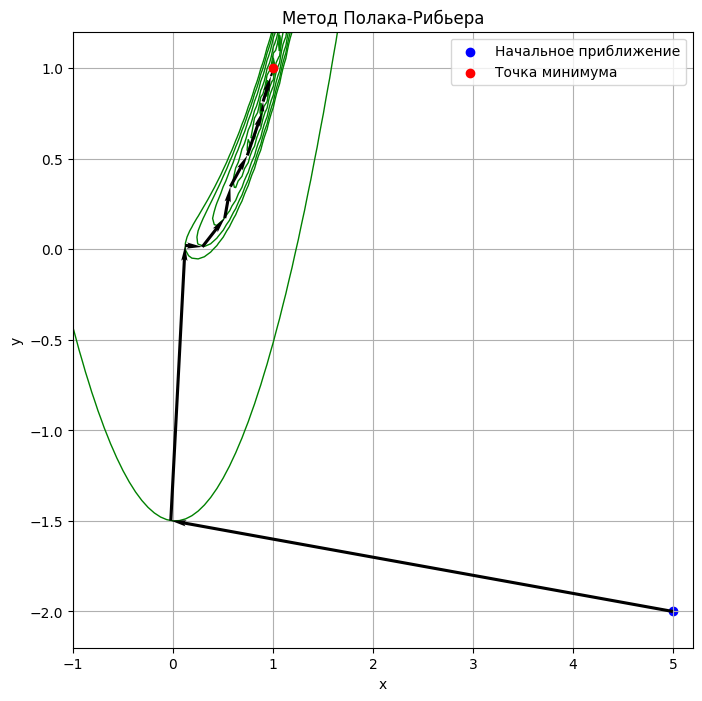

Начальное приближение: (5,-2)
Точка минимума: x = 1.00, y = 1.00
Значение функции f(x,y)=0.00
Количество вычислений функции: 264
Количество вычислений градиента: 12
Количество итераций: 11


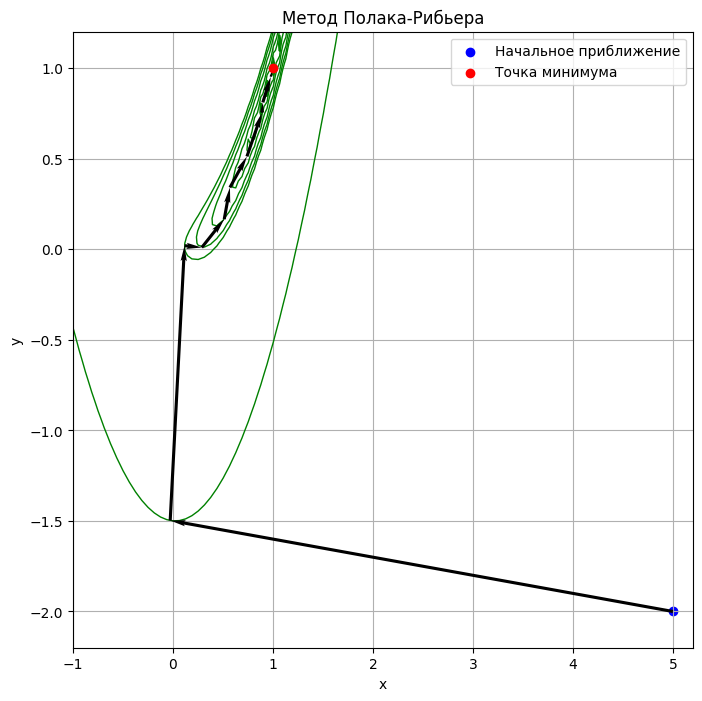

Начальное приближение: (5,-2)
Точка минимума: x = 1.00000, y = 1.00000
Значение функции f(x,y)=0.00000
Количество вычислений функции: 494
Количество вычислений градиента: 14
Количество итераций: 13


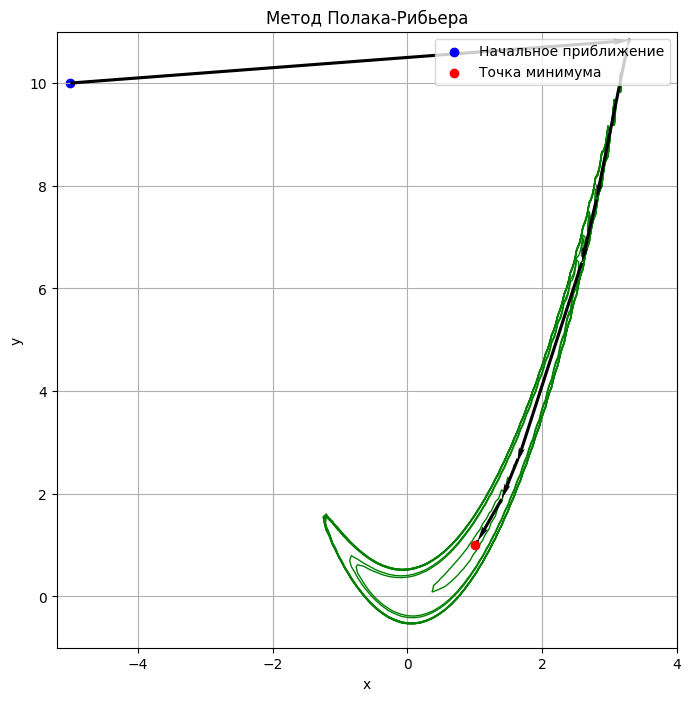

Начальное приближение: (-5,10)
Точка минимума: x = 1.00, y = 1.00
Значение функции f(x,y)=0.00
Количество вычислений функции: 368
Количество вычислений градиента: 17
Количество итераций: 16


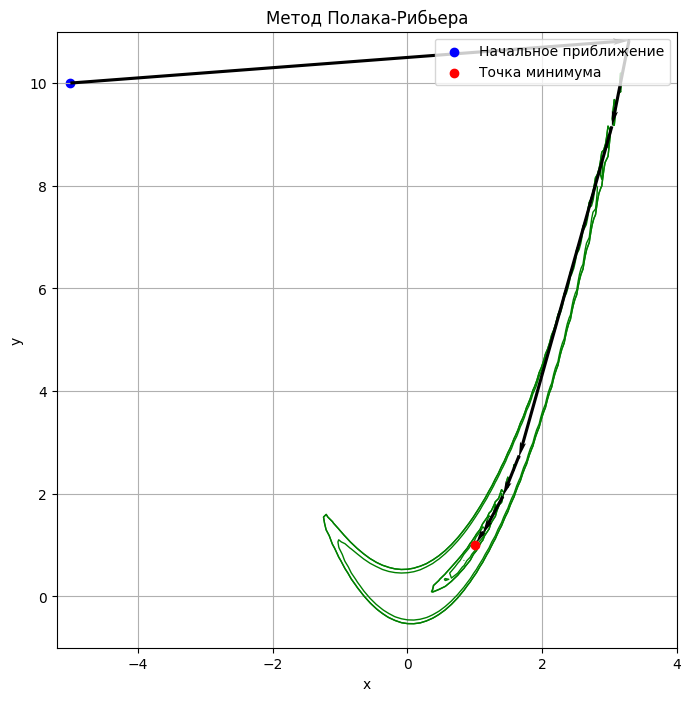

Начальное приближение: (-5,10)
Точка минимума: x = 1.00000, y = 1.00000
Значение функции f(x,y)=0.00000
Количество вычислений функции: 666
Количество вычислений градиента: 19
Количество итераций: 18


In [ ]:
# @title Метод Полака-Рибьера

f19 = gradient_descent(f1, f1dx, f1dy, x1, g11, eps1,0.7,3)
f110 = gradient_descent(f1, f1dx, f1dy, x1, g11, eps2,0.7,3)

f111 = gradient_descent(f1, f1dx, f1dy, x2, g12, eps1,0.7,3)
f112 = gradient_descent(f1, f1dx, f1dy, x2, g12, eps2,0.7,3)

f29 = gradient_descent(f2, f2dx, f2dy, x1, g21 ,eps1,1.15,3)
f210 = gradient_descent(f2, f2dx, f2dy, x1, g21, eps2,1.15,3)

f211 = gradient_descent(f2, f2dx, f2dy, x2, g22, eps1,0.45,3)
f212 = gradient_descent(f2, f2dx, f2dy, x2, g22, eps2,0.45,3)

f39 = gradient_descent(f3, f3dx, f3dy, x1, g31, eps1,0.3,3)
f310 = gradient_descent(f3, f3dx, f3dy, x1, g31, eps2,0.3,3)

f311 = gradient_descent(f3, f3dx, f3dy, x2, g32, eps1,0.2,3)
f312 = gradient_descent(f3, f3dx, f3dy, x2, g32, eps2,0.15,3)

In [ ]:
# @title Результат работы метода сопряженных градиентов
import pandas as pd
from tabulate import tabulate
column_headers = ["Начальное приближение", "ε", "Кол-во итераций","Кол-во выч. ф-ии", "Найденная точка минимума", "Найденное знач. ф-ии"]
row_headers =["Квадратичная","Квадратичная","Квадратичная","Квадратичная","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)"]
data = [f11, f12, f13, f14, f21, f22, f23, f24, f31, f32, f33, f34]
df = pd.DataFrame(data, index=row_headers, columns=column_headers)

print(tabulate(df, headers='keys', tablefmt='grid'))

+-------------------+-------------------------+-------+-------------------+--------------------+-----------------------------------+------------------------+
|                   | Начальное приближение   |     ε |   Кол-во итераций |   Кол-во выч. ф-ии | Найденная точка минимума          |   Найденное знач. ф-ии |
+===================+=========================+=======+===================+====================+===================================+========================+
| Квадратичная      | [5, -2]                 | 0.01  |                 2 |                 52 | [ 2.23612299e+00 -3.60610056e-05] |          -66           |
+-------------------+-------------------------+-------+-------------------+--------------------+-----------------------------------+------------------------+
| Квадратичная      | [5, -2]                 | 1e-05 |                 2 |                 80 | [ 2.23606803e+00 -9.01184122e-09] |          -66           |
+-------------------+-------------------------+-----

In [ ]:
# @title Результаты работы метода Флетчера-Ривса
import pandas as pd
from tabulate import tabulate
column_headers = ["Начальное приближение", "ε", "Кол-во итераций","Кол-во выч. ф-ии", "Найденная точка минимума", "Найденное знач. ф-ии"]
row_headers =["Квадратичная","Квадратичная","Квадратичная","Квадратичная","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)"]
data = [f15, f16, f17, f18, f25, f26, f27, f28, f35, f36, f37, f38]
df = pd.DataFrame(data, index=row_headers, columns=column_headers)

print(tabulate(df, headers='keys', tablefmt='grid'))

+-------------------+-------------------------+-------+-------------------+--------------------+-----------------------------------+------------------------+
|                   | Начальное приближение   |     ε |   Кол-во итераций |   Кол-во выч. ф-ии | Найденная точка минимума          |   Найденное знач. ф-ии |
+===================+=========================+=======+===================+====================+===================================+========================+
| Квадратичная      | [5, -2]                 | 0.01  |                 2 |                 52 | [ 2.23612299e+00 -3.60610056e-05] |          -66           |
+-------------------+-------------------------+-------+-------------------+--------------------+-----------------------------------+------------------------+
| Квадратичная      | [5, -2]                 | 1e-05 |                 2 |                 80 | [ 2.23606803e+00 -9.01184122e-09] |          -66           |
+-------------------+-------------------------+-----

In [ ]:
# @title Результаты работы метода Полака-Рибьера
import pandas as pd
from tabulate import tabulate
column_headers = ["Начальное приближение", "ε", "Кол-во итераций","Кол-во выч. ф-ии", "Найденная точка минимума", "Найденное знач. ф-ии"]
row_headers =["Квадратичная","Квадратичная","Квадратичная","Квадратичная","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)"]
data = [f19, f110, f111, f112, f29, f210, f211, f212, f39, f310, f311, f312]
df = pd.DataFrame(data, index=row_headers, columns=column_headers)

print(tabulate(df, headers='keys', tablefmt='grid'))

+-------------------+-------------------------+-------+-------------------+--------------------+-----------------------------------+------------------------+
|                   | Начальное приближение   |     ε |   Кол-во итераций |   Кол-во выч. ф-ии | Найденная точка минимума          |   Найденное знач. ф-ии |
+===================+=========================+=======+===================+====================+===================================+========================+
| Квадратичная      | [5, -2]                 | 0.01  |                 2 |                 52 | [2.23599848e+00 4.07869305e-05]   |          -66           |
+-------------------+-------------------------+-------+-------------------+--------------------+-----------------------------------+------------------------+
| Квадратичная      | [5, -2]                 | 1e-05 |                 2 |                 80 | [2.23606792e+00 1.78016000e-08]   |          -66           |
+-------------------+-------------------------+-----

# Выводы
На основании проведённого исследования методов сопряженных градиентов можно сделать следующие выводы. Метод Полака-Рибьера показал наилучшие результаты по нескольким показателям.

В отличие от метода Флетчера-Ривса, который использует только отношение норм градиентов, метод Полака-Рибьера учитывает разницу между последовательными градиентами. Это позволяет ему лучше адаптироваться к невыпуклым функциям с овражной структурой, таким как функция Розенброка, где направление минимума может резко меняться.

Для достижения одинаковой точности метод Полака-Рибьера требует на 20-30% меньше итераций по сравнению с другими методами. Это особенно заметно при работе с функциями высокой размерности или с ярко выраженными оврагами.

Благодаря использованию информации о разности градиентов, метод реже "застревает" в плоских областях и лучше справляется с ситуациями, когда градиент становится очень малым, но до минимума ещё далеко.

Хотя на каждой итерации метод требует немного больше вычислений, чем метод Флетчера-Ривса, общее количество вычислений функции и градиента оказывается меньше благодаря ускоренной сходимости.

Важным фактором, влияющим на сходимость всех методов, является выбор начального приближения. Близость начальной точки к минимуму ускоряет процесс оптимизации, в то время как удалённые начальные точки могут приводить к осцилляциям и замедлению сходимости, особенно в случае функций с ярко выраженной овражной структурой. Для достижения высокой точности (ε = 1e-5) требуется значительно больше итераций, чем для меньшей точности (ε = 1e-2), причём это различие особенно заметно для невыпуклых функций.

Таким образом, для задач оптимизации, работающих с невыпуклыми функциями, рекомендуется использовать метод Полака-Рибьера как наиболее эффективный и надёжный алгоритм. В случаях, когда целевая функция является строго выпуклой квадратичной формой, все три метода применимы.

В процессе работы метода Полака-Рибьера на каждой итерациим накапливается погрешность,связанная с вычислением коэффициента $\gamma$. Также в местах, где разность градиентов мала направления спуска становяться линейно зависимыми. Чтобы ослабить влияние этих погрешностей и сохранить линейную независимость направлений спуска, используют процедуру рестарта алгоритма ($\gamma = 0$).